# 03 — Similarity & Clustering: Cell Lines, Drugs, and Pairs

**Goal (diagnostic, not modeling):** understand how similar/redundant cell lines and
drugs are to each other by modality, to anticipate how "hard" the LCO/LDO/LTO splits
actually are. This complements DrEval's Normalized PCC metric — it doesn't replace it;
the splits + normalized metric are what structurally guard against Simpson's paradox.

1. Highly variable feature (HVG) selection, RNA and protein separately
2. Cell line clustering per modality + agreement between modalities (Adjusted Rand Index)
3. Drug structural similarity + clustering (Tanimoto on Morgan fingerprints)
4. Pair-level response heterogeneity: within-cluster vs across-cluster variance

> Column names below are assumed from `SESSION_MEMORY.md` — verify against actual
> headers in the CONFIG cell before running.

## Config

In [41]:
from pathlib import Path

DATA_DIR = Path("../data/GDSC2")
RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures"
PROCESSED_DIR = Path("../data/processed")
TABLES_DIR = RESULTS_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COL_CELL_LINE = "cell_line_name"
COL_DRUG = "drug_name"
COL_SMILES = "canonical_smiles"
COL_IC50 = "LN_IC50"
COL_CELLOSAURUS = "cellosaurus_id"
COL_TISSUE = "tissue"

N_HVG = 2000
N_CLUSTERS_CELL = 8
N_CLUSTERS_DRUG = 8
RANDOM_STATE = 42

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

sns.set_theme(style="whitegrid")

## Load data (same three-way overlap logic as notebook 02)

In [13]:
rna = pd.read_csv(DATA_DIR / "gene_expression.csv", index_col=0)
protein = pd.read_csv(DATA_DIR / "proteomics.csv", index_col=0)
cell_lines = pd.read_csv(DATA_DIR / "cell_line_names.csv")
gdsc = pd.read_csv(DATA_DIR / "GDSC2.csv")
drug_smiles = pd.read_csv(DATA_DIR / "drug_smiles.csv")

rna = rna[~rna.index.duplicated(keep="first")]
protein = protein[~protein.index.duplicated(keep="first")]


def three_way_overlap(
    rna_df: pd.DataFrame,
    protein_df: pd.DataFrame,
    gdsc_df: pd.DataFrame,
    mapping_df: pd.DataFrame,
) -> list[str]:
    """Cellosaurus IDs present in RNA, protein, and GDSC2 response data."""
    name_to_id = dict(zip(mapping_df[COL_CELL_LINE], mapping_df[COL_CELLOSAURUS]))
    gdsc_ids = set(gdsc_df[COL_CELL_LINE].map(name_to_id).dropna())
    return sorted(set(rna_df.index) & set(protein_df.index) & gdsc_ids)


common_ids = three_way_overlap(rna, protein, gdsc, cell_lines)
tissue_lookup = cell_lines.set_index(COL_CELLOSAURUS)[COL_TISSUE]
len(common_ids)

/tmp/ipykernel_5077/3939936660.py:4: DtypeWarning: Columns (2,25) have mixed types. Specify dtype option on import or set low_memory=False.
  gdsc = pd.read_csv(DATA_DIR / "GDSC2.csv")


836

In [14]:
import mygene

mg = mygene.MyGeneInfo()
uniprot_ids = [col.split(";")[0] for col in protein.columns]

mapping = mg.querymany(
    uniprot_ids, scopes="uniprot", fields="symbol", species="human", as_dataframe=True
)

def align_protein_to_gene_symbols(protein_df: pd.DataFrame, mapping_df: pd.DataFrame) -> pd.DataFrame:
    """Rename protein columns to official gene symbols via UniProt accession -> HGNC symbol lookup."""
    acc_to_symbol = mapping_df["symbol"].dropna().to_dict()
    gene_map = {}
    for col in protein_df.columns:
        acc = col.split(";")[0]
        symbol = acc_to_symbol.get(acc)
        if symbol:
            gene_map.setdefault(symbol, col)

    aligned = protein_df[list(gene_map.values())].copy()
    aligned.columns = list(gene_map.keys())
    return aligned

protein_aligned = align_protein_to_gene_symbols(protein, mapping)
print(f"Genes matched with UniProt-accession mapping: {protein_aligned.shape[1]}")

22 input query terms found dup hits:	[('Q96PK6', 2), ('P23610', 3), ('P69905', 2), ('Q5JQC4', 10), ('Q9Y3E7', 2), ('A8MYA2', 2), ('P78358
24 input query terms found no hit:	['P01854', 'Q9UKY3', 'P01880', 'Q9UN81', 'P01860', 'P01876', 'P01871', 'Q58FG1', 'P01834', 'P51784',


Genes matched with UniProt-accession mapping: 6667


## 1. Highly variable feature selection (HVG)

In [15]:
def select_hvg(
    df: pd.DataFrame, cell_ids: list[str], n_top: int = 2000, n_bins: int = 20
) -> list[str]:
    """Top variable features, normalizing dispersion within mean-expression bins
    (Seurat-style) so highly-expressed features don't dominate by raw variance alone."""
    sub = df.loc[cell_ids].select_dtypes(include=[np.number])
    mean = sub.mean(axis=0)
    var = sub.var(axis=0)
    dispersion = var / mean.replace(0, np.nan)

    bins = pd.qcut(mean.rank(method="first"), n_bins, labels=False)
    z_dispersion = dispersion.groupby(bins).transform(lambda x: (x - x.mean()) / x.std(ddof=0))
    return z_dispersion.sort_values(ascending=False).head(n_top).index.tolist()


hvg_rna = select_hvg(rna, common_ids, N_HVG)
hvg_protein = select_hvg(protein_aligned, common_ids, N_HVG)
len(hvg_rna), len(hvg_protein), len(set(hvg_rna) & set(hvg_protein))

(2000, 2000, 582)

## 2. Cell line clustering — RNA vs Protein

### PCA

In [16]:
from sklearn.impute import SimpleImputer

def cluster_cell_lines(
    df: pd.DataFrame, cell_ids: list[str], features: list[str], n_clusters: int
) -> tuple[np.ndarray, np.ndarray]:
    """Z-score, PCA to 20 components, KMeans. Returns (pca_coords, cluster_labels).
    Missing values are mean-imputed per feature before scaling, so cell lines aren't
    clustered by missingness pattern rather than biology."""
    X_raw = df.loc[cell_ids, features]
    X_imputed = SimpleImputer(strategy="mean").fit_transform(X_raw)
    X = StandardScaler().fit_transform(X_imputed)
    pcs = PCA(n_components=20, random_state=RANDOM_STATE).fit_transform(X)
    labels = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10).fit_predict(pcs)
    return pcs, labels


rna_pcs, rna_clusters = cluster_cell_lines(rna, common_ids, hvg_rna, N_CLUSTERS_CELL)
protein_pcs, protein_clusters = cluster_cell_lines(protein_aligned, common_ids, hvg_protein, N_CLUSTERS_CELL)

ari = adjusted_rand_score(rna_clusters, protein_clusters)
print(f"Adjusted Rand Index (RNA clusters vs Protein clusters): {ari:.3f}")

Adjusted Rand Index (RNA clusters vs Protein clusters): 0.417


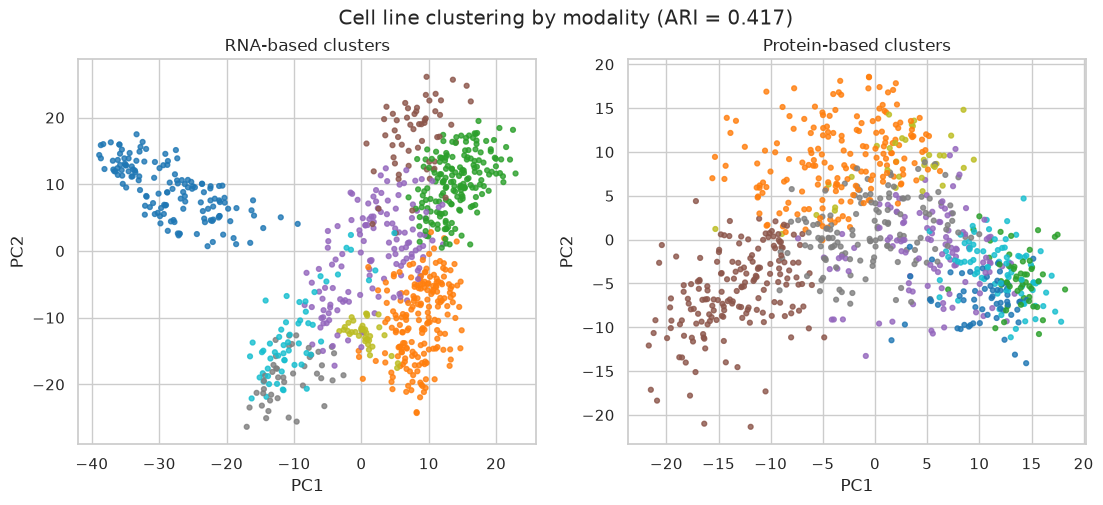

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pcs, clusters, title in [
    (axes[0], rna_pcs, rna_clusters, "RNA-based clusters"),
    (axes[1], protein_pcs, protein_clusters, "Protein-based clusters"),
]:
    ax.scatter(pcs[:, 0], pcs[:, 1], c=clusters, cmap="tab10", s=12, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
fig.suptitle(f"Cell line clustering by modality (ARI = {ari:.3f})")
fig.savefig(FIGURES_DIR / "fig2_cell_line_clusters_rna_vs_protein.png", dpi=200, bbox_inches="tight")

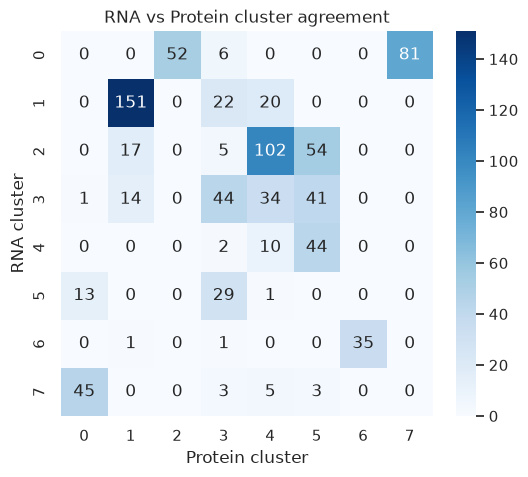

In [18]:
contingency = pd.crosstab(
    pd.Series(rna_clusters, name="RNA cluster"),
    pd.Series(protein_clusters, name="Protein cluster"),
)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("RNA vs Protein cluster agreement")
fig.savefig(FIGURES_DIR / "fig3_cluster_agreement_heatmap.png", dpi=200, bbox_inches="tight")

### UMAP

In [29]:
import umap

def cluster_cell_lines_umap(
    df: pd.DataFrame, cell_ids: list[str], features: list[str], n_clusters: int, n_pca: int = 20,
) -> tuple[np.ndarray, np.ndarray]:
    """Impute, scale, PCA (denoise), then UMAP to 2D, then KMeans on the UMAP embedding.
    Returns (umap_coords, cluster_labels)."""
    X_raw = df.loc[cell_ids, features]
    X_imputed = SimpleImputer(strategy="mean").fit_transform(X_raw)
    X = StandardScaler().fit_transform(X_imputed)
    pcs = PCA(n_components=n_pca, random_state=RANDOM_STATE).fit_transform(X)
    embedding = umap.UMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(pcs)
    labels = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10).fit_predict(embedding)
    return embedding, labels


rna_umap, rna_clusters_umap = cluster_cell_lines_umap(rna, common_ids, hvg_rna, N_CLUSTERS_CELL)
protein_umap, protein_clusters_umap = cluster_cell_lines_umap(protein_aligned, common_ids, hvg_protein, N_CLUSTERS_CELL)

ari_umap = adjusted_rand_score(rna_clusters_umap, protein_clusters_umap)
print(f"Adjusted Rand Index (UMAP-based, RNA vs Protein): {ari_umap:.3f}")

/home/shoko/miniconda3/envs/multiomics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/shoko/miniconda3/envs/multiomics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Adjusted Rand Index (UMAP-based, RNA vs Protein): 0.416


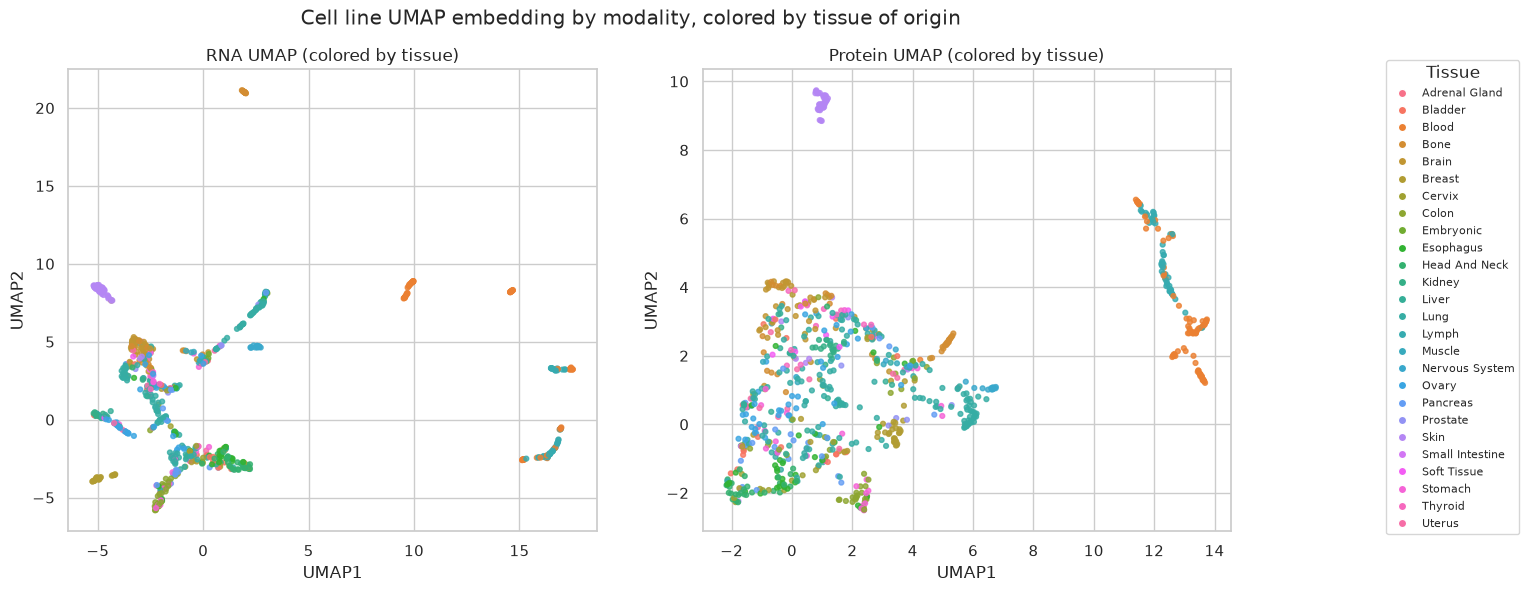

In [30]:
tissues_for_plot = tissue_lookup.loc[common_ids].values
unique_tissues = sorted(pd.unique(tissues_for_plot))
palette = sns.color_palette("husl", len(unique_tissues))
tissue_to_color = dict(zip(unique_tissues, palette))
point_colors = [tissue_to_color[t] for t in tissues_for_plot]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, emb, title in [
    (axes[0], rna_umap, "RNA UMAP (colored by tissue)"),
    (axes[1], protein_umap, "Protein UMAP (colored by tissue)"),
]:
    ax.scatter(emb[:, 0], emb[:, 1], c=point_colors, s=12, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=tissue_to_color[t], markersize=6, label=t)
    for t in unique_tissues
]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, title="Tissue")
fig.suptitle("Cell line UMAP embedding by modality, colored by tissue of origin")
fig.savefig(FIGURES_DIR / "fig2b_umap_by_tissue.png", dpi=200, bbox_inches="tight")

### tSNE

In [34]:
from sklearn.manifold import TSNE

def cluster_cell_lines_tsne(
    df: pd.DataFrame, cell_ids: list[str], features: list[str], n_clusters: int, n_pca: int = 20,
) -> tuple[np.ndarray, np.ndarray]:
    """Impute, scale, PCA (denoise), then t-SNE to 2D, then KMeans on the t-SNE embedding.
    Returns (tsne_coords, cluster_labels)."""
    X_raw = df.loc[cell_ids, features]
    X_imputed = SimpleImputer(strategy="mean").fit_transform(X_raw)
    X = StandardScaler().fit_transform(X_imputed)
    pcs = PCA(n_components=n_pca, random_state=RANDOM_STATE).fit_transform(X)
    embedding = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", perplexity=30).fit_transform(pcs)
    labels = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10).fit_predict(embedding)
    return embedding, labels


rna_tsne, rna_clusters_tsne = cluster_cell_lines_tsne(rna, common_ids, hvg_rna, N_CLUSTERS_CELL)
protein_tsne, protein_clusters_tsne = cluster_cell_lines_tsne(protein_aligned, common_ids, hvg_protein, N_CLUSTERS_CELL)

ari_tsne = adjusted_rand_score(rna_clusters_tsne, protein_clusters_tsne)
print(f"Adjusted Rand Index (t-SNE-based, RNA vs Protein): {ari_tsne:.3f}")

Adjusted Rand Index (t-SNE-based, RNA vs Protein): 0.539


### PLot

In [31]:
def plot_embedding(ax, coords, color_values, title, palette=None, is_categorical=False):
    """Scatter an embedding colored by cluster labels (int, tab10) or tissue (categorical, husl)."""
    if is_categorical:
        ax.scatter(coords[:, 0], coords[:, 1], c=[palette[v] for v in color_values], s=12, alpha=0.8)
    else:
        ax.scatter(coords[:, 0], coords[:, 1], c=color_values, cmap="tab10", s=12, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")


tissue_legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=tissue_to_color[t], markersize=6, label=t)
    for t in unique_tissues
]

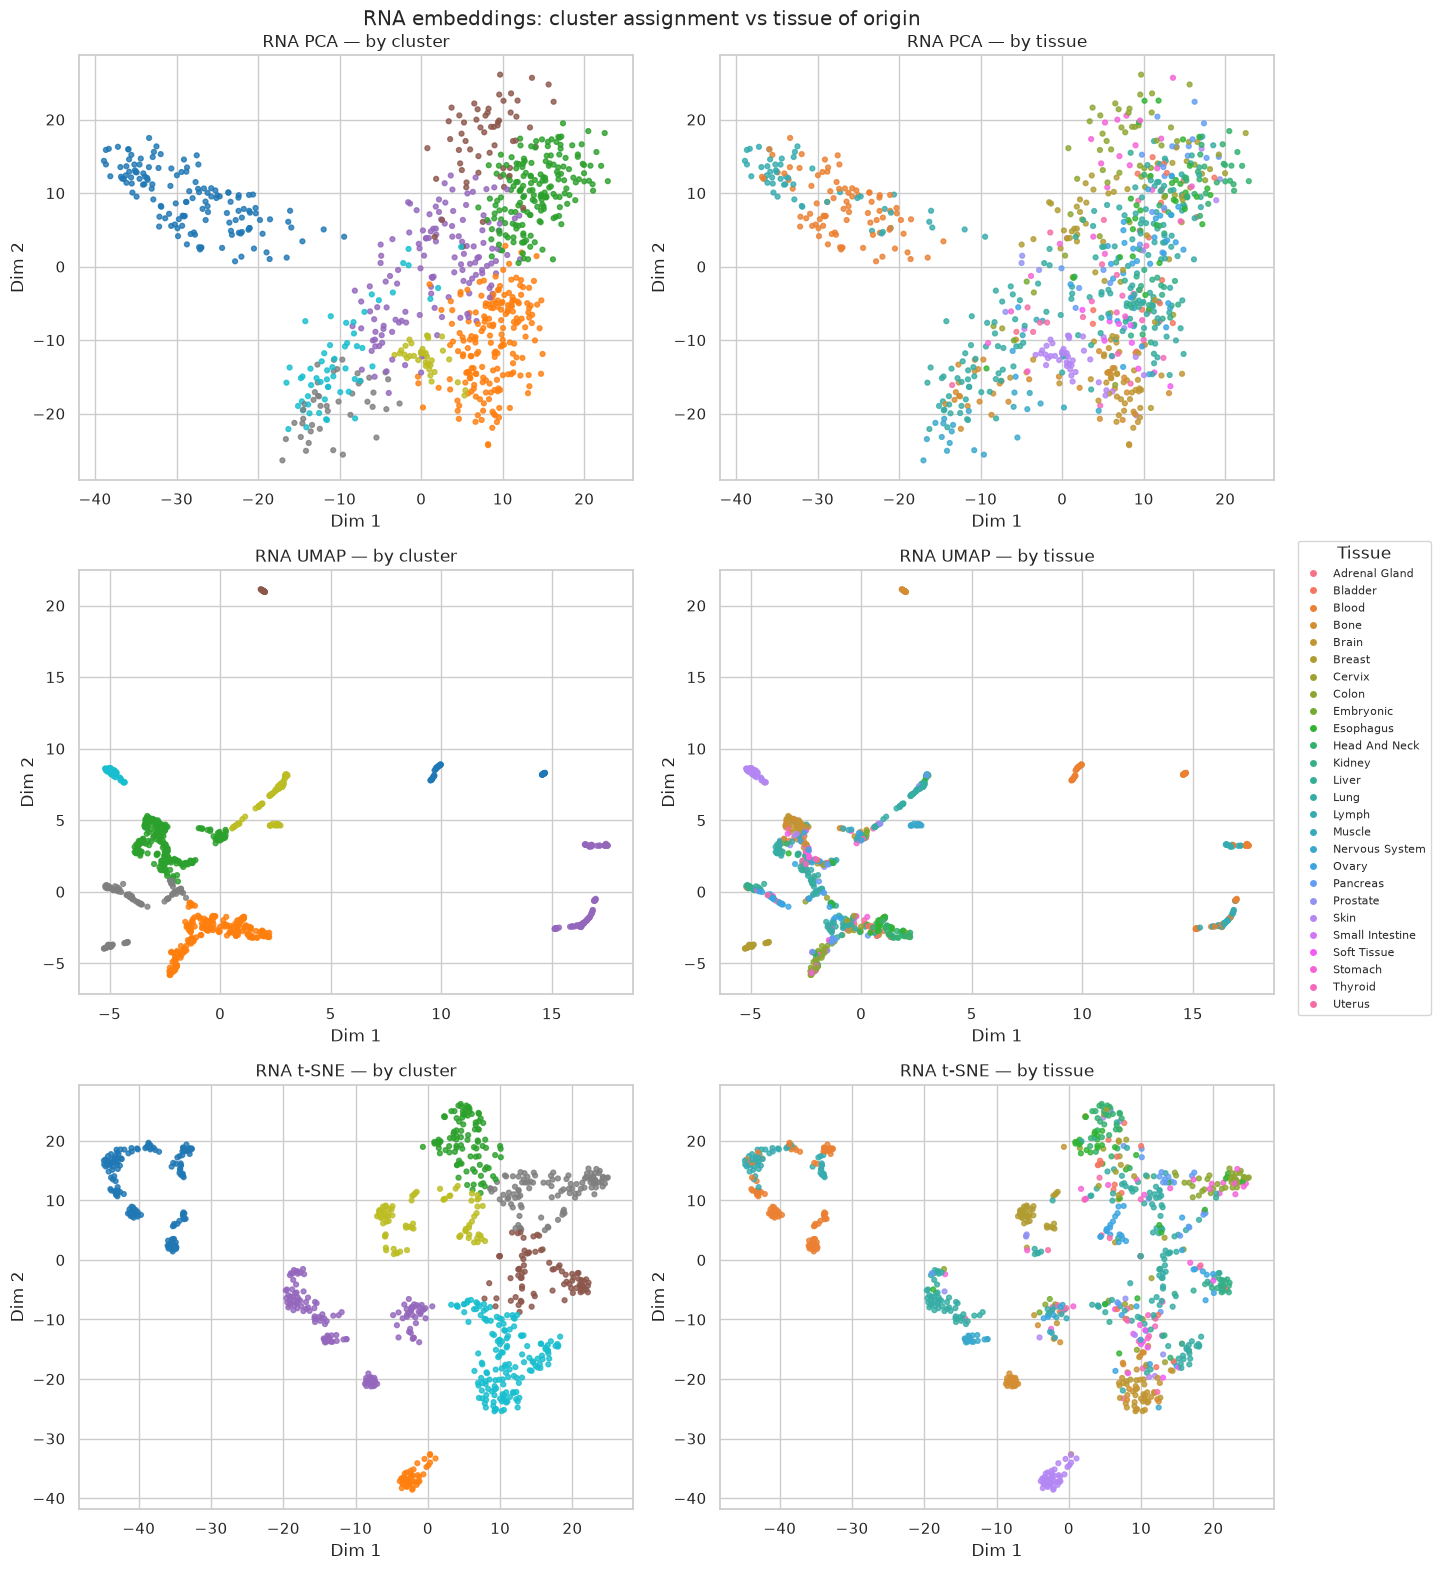

In [35]:
fig, axes = plt.subplots(3, 2, figsize=(13, 16))
plot_embedding(axes[0, 0], rna_pcs[:, :2], rna_clusters, "RNA PCA — by cluster")
plot_embedding(axes[0, 1], rna_pcs[:, :2], tissues_for_plot, "RNA PCA — by tissue",
                palette=tissue_to_color, is_categorical=True)
plot_embedding(axes[1, 0], rna_umap, rna_clusters_umap, "RNA UMAP — by cluster")
plot_embedding(axes[1, 1], rna_umap, tissues_for_plot, "RNA UMAP — by tissue",
                palette=tissue_to_color, is_categorical=True)
plot_embedding(axes[2, 0], rna_tsne, rna_clusters_tsne, "RNA t-SNE — by cluster")
plot_embedding(axes[2, 1], rna_tsne, tissues_for_plot, "RNA t-SNE — by tissue",
                palette=tissue_to_color, is_categorical=True)
fig.suptitle("RNA embeddings: cluster assignment vs tissue of origin")
fig.legend(handles=tissue_legend_handles, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, title="Tissue")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig2e_rna_pca_umap_tsne_cluster_tissue.png", dpi=200, bbox_inches="tight")

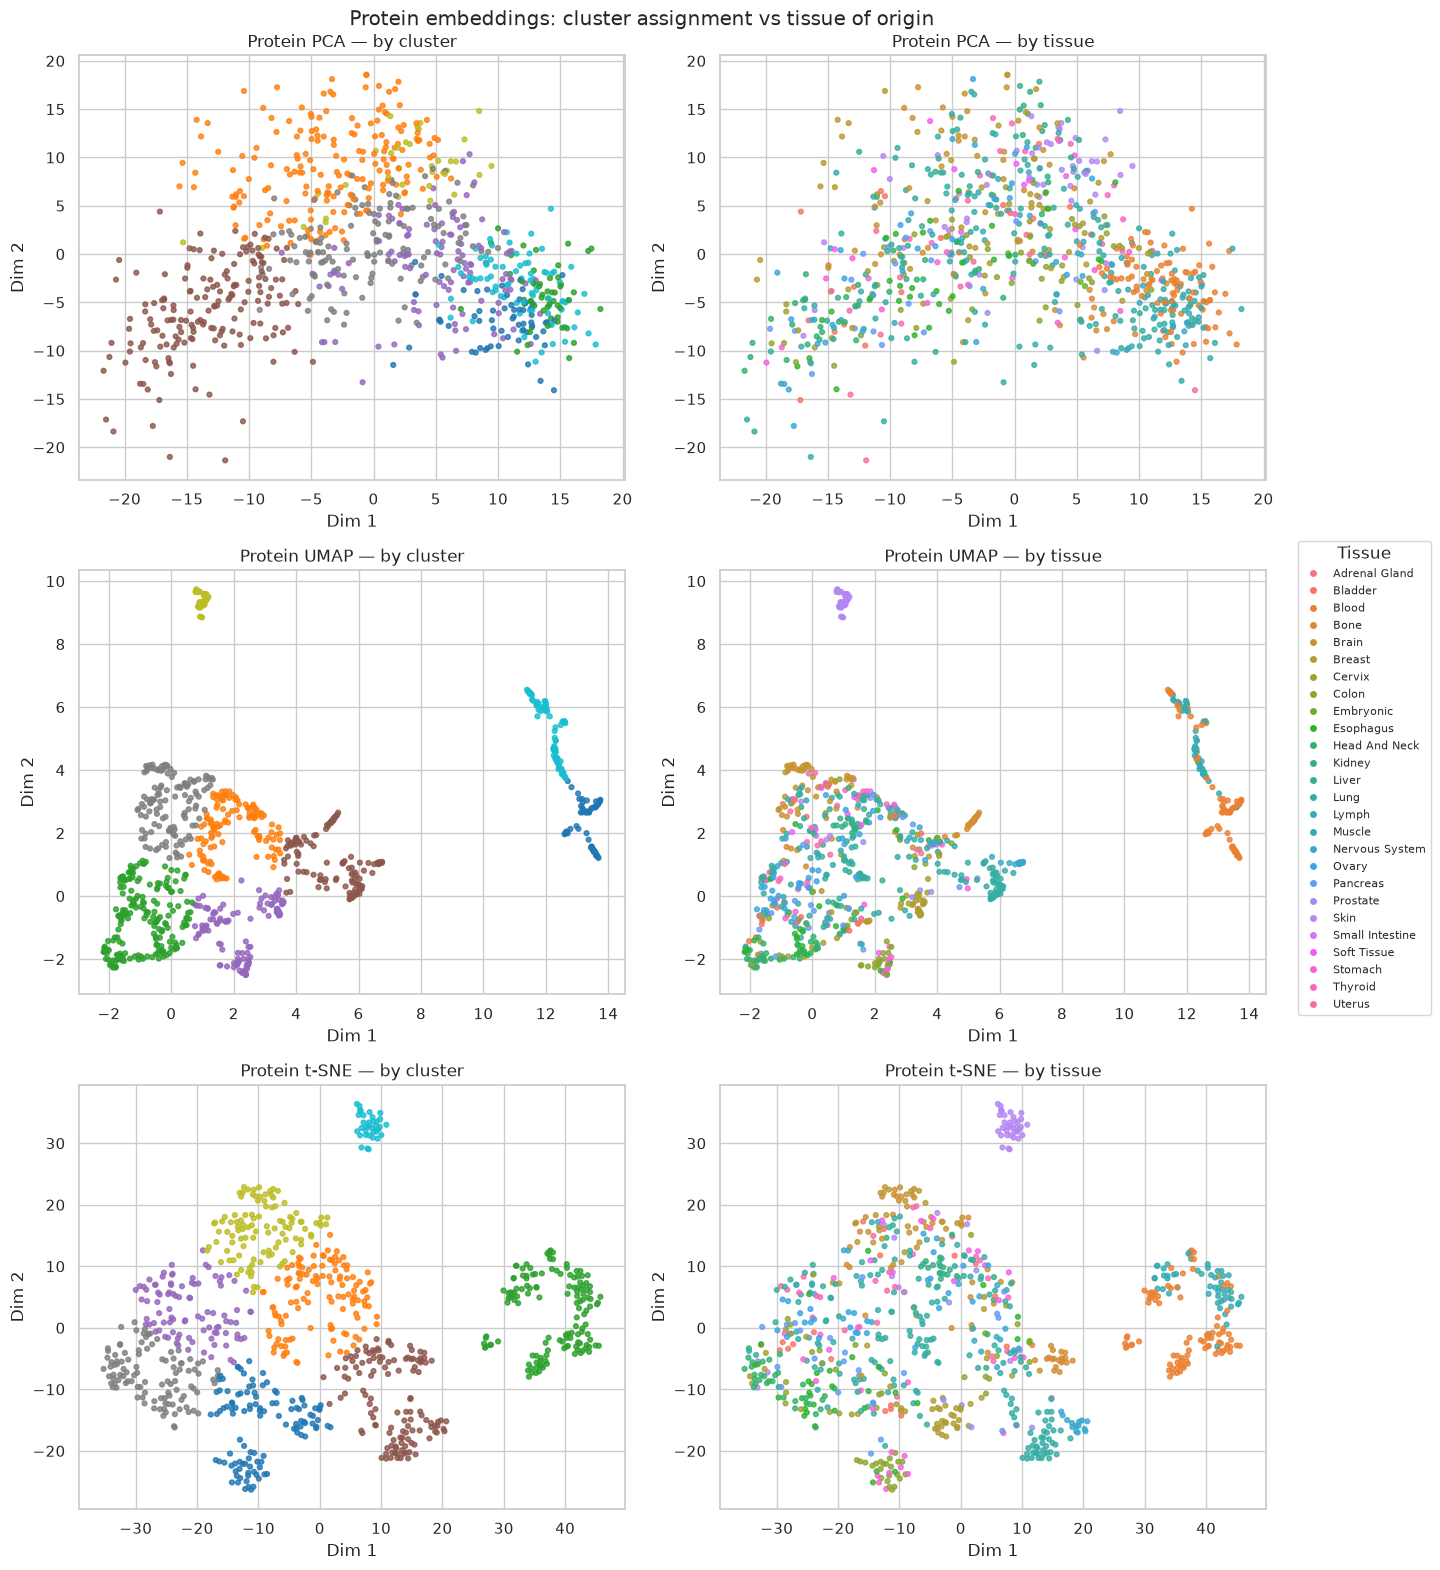

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(13, 16))
plot_embedding(axes[0, 0], protein_pcs[:, :2], protein_clusters, "Protein PCA — by cluster")
plot_embedding(axes[0, 1], protein_pcs[:, :2], tissues_for_plot, "Protein PCA — by tissue",
                palette=tissue_to_color, is_categorical=True)
plot_embedding(axes[1, 0], protein_umap, protein_clusters_umap, "Protein UMAP — by cluster")
plot_embedding(axes[1, 1], protein_umap, tissues_for_plot, "Protein UMAP — by tissue",
                palette=tissue_to_color, is_categorical=True)
plot_embedding(axes[2, 0], protein_tsne, protein_clusters_tsne, "Protein t-SNE — by cluster")
plot_embedding(axes[2, 1], protein_tsne, tissues_for_plot, "Protein t-SNE — by tissue",
                palette=tissue_to_color, is_categorical=True)
fig.suptitle("Protein embeddings: cluster assignment vs tissue of origin")
fig.legend(handles=tissue_legend_handles, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, title="Tissue")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig2f_protein_pca_umap_tsne_cluster_tissue.png", dpi=200, bbox_inches="tight")

In [37]:
def cluster_tissue_composition(
    cluster_labels: np.ndarray, cell_ids: list[str], tissue: pd.Series
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """For each cluster: size, majority tissue label, and the fraction that tissue makes up.
    Also returns the full tissue x cluster crosstab for detailed inspection."""
    tissue_for_ids = tissue.loc[cell_ids].values
    df = pd.DataFrame({"cluster": cluster_labels, "tissue": tissue_for_ids})
    composition = pd.crosstab(df["cluster"], df["tissue"])

    summary = pd.DataFrame({
        "n_cells": composition.sum(axis=1),
        "majority_tissue": composition.idxmax(axis=1),
        "majority_fraction": composition.max(axis=1) / composition.sum(axis=1),
    })
    return summary, composition


protein_umap_summary, protein_umap_composition = cluster_tissue_composition(
    protein_clusters_umap, common_ids, tissue_lookup
)
protein_tsne_summary, protein_tsne_composition = cluster_tissue_composition(
    protein_clusters_tsne, common_ids, tissue_lookup
)
rna_umap_summary, _ = cluster_tissue_composition(rna_clusters_umap, common_ids, tissue_lookup)

print("Protein UMAP clusters — sorted by tissue purity:")
print(protein_umap_summary.sort_values("majority_fraction", ascending=False))
print("\nProtein t-SNE clusters — sorted by tissue purity:")
print(protein_tsne_summary.sort_values("majority_fraction", ascending=False))
print("\nRNA UMAP clusters — sorted by tissue purity (for comparison):")
print(rna_umap_summary.sort_values("majority_fraction", ascending=False))

Protein UMAP clusters — sorted by tissue purity:
         n_cells majority_tissue  majority_fraction
cluster                                            
6             35            Skin           1.000000
0             62           Blood           0.951613
7             76           Lymph           0.644737
4            116            Lung           0.482759
1            125            Lung           0.344000
5            125           Brain           0.344000
3            109          Breast           0.275229
2            188            Lung           0.202128

Protein t-SNE clusters — sorted by tissue purity:
         n_cells majority_tissue  majority_fraction
cluster                                            
7             35            Skin           1.000000
2            138           Blood           0.623188
4            124            Lung           0.459677
6            106           Brain           0.396226
1            122            Lung           0.344262
3             94

## 3. Drug structural similarity

In [20]:
drug_smiles.columns

Index(['pubchem_id', 'drug_name', 'canonical_smiles', 'cactvs_fingerprint',
       'fingerprint'],
      dtype='object')

In [23]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smiles: str):
    """Morgan fingerprint (radius=2, 2048 bits) as an RDKit ExplicitBitVect, or None if SMILES is invalid."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return morgan_gen.GetFingerprint(mol)


def drug_tanimoto_matrix(
    smiles_df: pd.DataFrame, drug_col: str, smiles_col: str
) -> tuple[pd.DataFrame, list[str]]:
    """Pairwise Tanimoto similarity matrix for all drugs with a valid SMILES string."""
    fps, names = [], []
    for _, row in smiles_df.iterrows():
        fp = smiles_to_fingerprint(row[smiles_col])
        if fp is not None:
            fps.append(fp)
            names.append(row[drug_col])

    n = len(fps)
    sim = np.zeros((n, n))
    for i in range(n):
        sim[i] = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    return pd.DataFrame(sim, index=names, columns=names), names


drug_sim, drug_names = drug_tanimoto_matrix(drug_smiles, COL_DRUG, COL_SMILES)
drug_sim.shape

(246, 246)

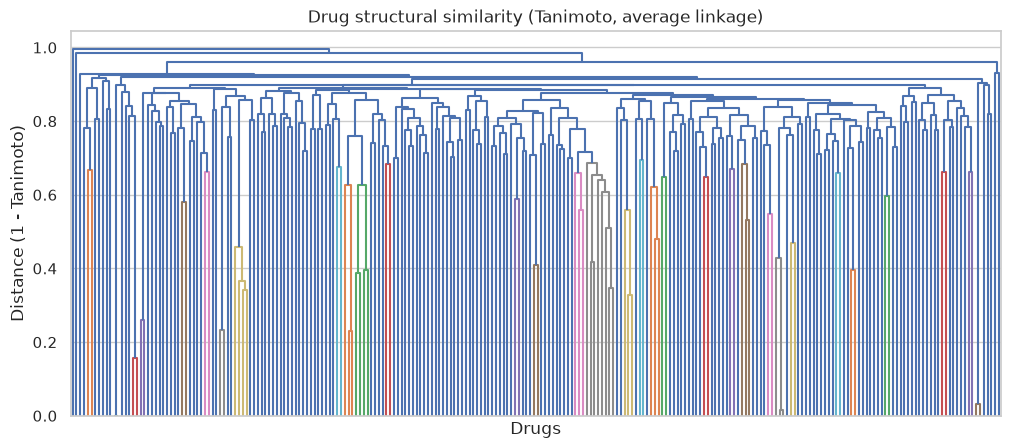

In [24]:
drug_dist = 1 - drug_sim.values
np.fill_diagonal(drug_dist, 0)
condensed = squareform(drug_dist, checks=False)
drug_linkage = linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(drug_linkage, labels=drug_names, no_labels=True, ax=ax)
ax.set_title("Drug structural similarity (Tanimoto, average linkage)")
ax.set_xlabel("Drugs")
ax.set_ylabel("Distance (1 - Tanimoto)")
fig.savefig(FIGURES_DIR / "fig4_drug_dendrogram.png", dpi=200, bbox_inches="tight")

Median pairwise similarity: 0.104
Fraction of pairs with similarity > 0.4: 0.001
Fraction of pairs with similarity > 0.7: 0.000


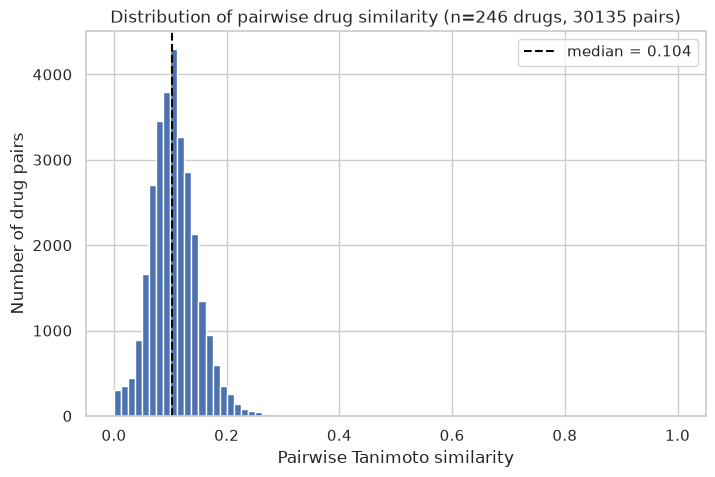

In [38]:
mask = np.triu(np.ones(drug_sim.shape, dtype=bool), k=1)
pairwise_sims = drug_sim.values[mask]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pairwise_sims, bins=80, color="#4C72B0", edgecolor="white")
ax.axvline(np.median(pairwise_sims), color="black", linestyle="--",
           label=f"median = {np.median(pairwise_sims):.3f}")
ax.set_xlabel("Pairwise Tanimoto similarity")
ax.set_ylabel("Number of drug pairs")
ax.set_title(f"Distribution of pairwise drug similarity (n={len(drug_names)} drugs, {mask.sum()} pairs)")
ax.legend()
fig.savefig(FIGURES_DIR / "fig4b_drug_similarity_distribution.png", dpi=200, bbox_inches="tight")

print(f"Median pairwise similarity: {np.median(pairwise_sims):.3f}")
print(f"Fraction of pairs with similarity > 0.4: {(pairwise_sims > 0.4).mean():.3f}")
print(f"Fraction of pairs with similarity > 0.7: {(pairwise_sims > 0.7).mean():.3f}")

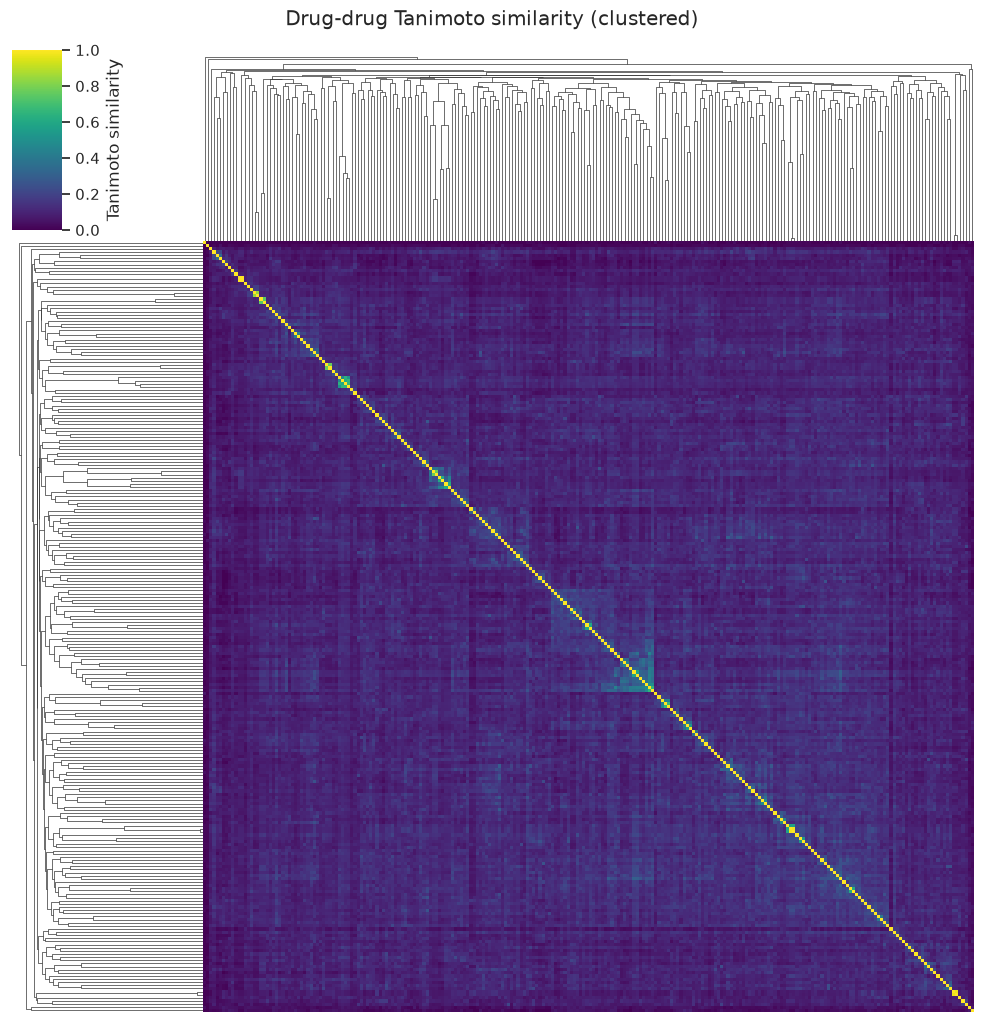

In [39]:
clustermap = sns.clustermap(
    drug_sim, row_linkage=drug_linkage, col_linkage=drug_linkage,
    cmap="viridis", figsize=(10, 10), xticklabels=False, yticklabels=False,
    cbar_kws={"label": "Tanimoto similarity"},
)
clustermap.fig.suptitle("Drug-drug Tanimoto similarity (clustered)", y=1.02)
clustermap.savefig(FIGURES_DIR / "fig4c_drug_similarity_clustermap.png", dpi=200, bbox_inches="tight")

In [42]:
def top_similar_pairs(sim_df: pd.DataFrame, n: int = 20) -> pd.DataFrame:
    """Top-n most similar drug pairs (excluding self-similarity and duplicate ordering)."""
    iu = np.triu_indices(len(sim_df), k=1)
    pairs_df = pd.DataFrame({
        "drug_a": sim_df.index[iu[0]],
        "drug_b": sim_df.columns[iu[1]],
        "tanimoto": sim_df.values[iu],
    })
    return pairs_df.sort_values("tanimoto", ascending=False).head(n)


top_pairs = top_similar_pairs(drug_sim, n=20)
top_pairs.to_csv(TABLES_DIR / "top_similar_drug_pairs.csv", index=False)
top_pairs

,drug_a,drug_b,tanimoto
11600,Bleomycin,Bleomycin (50 uM),1.000000
14306,GSK2110183B,Afuresertib,0.983051
7352,GSK-LSD1,GSK-LSD1-2HCl,0.966667
1478,Rapamycin,Temsirolimus,0.842105
4463,SGC0946,EPZ004777,0.771084
247,Paclitaxel,Docetaxel,0.767677
1933,Vinorelbine,Vinblastine,0.738739
23208,JQ-1,OTX015,0.671429
797,SN-38,Topotecan,0.657534
1755,Camptothecin,Topotecan,0.657143


In [43]:
thresholds = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]
rows = []
for t in thresholds:
    labels = fcluster(drug_linkage, t, criterion="distance")
    rows.append({
        "distance_threshold": t,
        "n_clusters": len(set(labels)),
        "largest_cluster_size": pd.Series(labels).value_counts().max(),
    })
pd.DataFrame(rows)

,distance_threshold,n_clusters,largest_cluster_size
0,0.9,12,221
1,0.8,116,13
2,0.7,196,8
3,0.6,218,4
4,0.5,226,4
5,0.4,232,3
6,0.3,239,2


## 4. Pair-level heterogeneity — within vs across clusters

In [25]:
drug_cluster_labels = fcluster(drug_linkage, N_CLUSTERS_DRUG, criterion="maxclust")
drug_cluster_map = dict(zip(drug_names, drug_cluster_labels))
cell_cluster_map = dict(zip(common_ids, rna_clusters))  # RNA-based, treated as primary modality

name_to_id = dict(zip(cell_lines[COL_CELL_LINE], cell_lines[COL_CELLOSAURUS]))
pairs = gdsc[gdsc[COL_DRUG].isin(drug_cluster_map)].copy()
pairs[COL_CELLOSAURUS] = pairs[COL_CELL_LINE].map(name_to_id)
pairs = pairs[pairs[COL_CELLOSAURUS].isin(cell_cluster_map)]

pairs["cell_cluster"] = pairs[COL_CELLOSAURUS].map(cell_cluster_map)
pairs["drug_cluster"] = pairs[COL_DRUG].map(drug_cluster_map)
pairs.shape

(177785, 35)

In [26]:
def within_vs_across_variance(df: pd.DataFrame, value_col: str, group_col: str) -> pd.DataFrame:
    """Mean within-cluster variance vs overall (across-cluster) variance of value_col, per drug."""
    rows = []
    for drug, sub in df.groupby(COL_DRUG):
        if sub[group_col].nunique() < 2:
            continue
        within = sub.groupby(group_col)[value_col].var().mean()
        across = sub[value_col].var()
        rows.append({"drug": drug, "within_cluster_var": within, "across_cluster_var": across})
    return pd.DataFrame(rows)


variance_df = within_vs_across_variance(pairs, COL_IC50, "cell_cluster")
variance_df["ratio"] = variance_df["within_cluster_var"] / variance_df["across_cluster_var"]
variance_df.to_csv(PROCESSED_DIR / "pair_variance_within_vs_across_cell_clusters.csv", index=False)
variance_df["ratio"].median()

np.float64(0.7602189378245857)

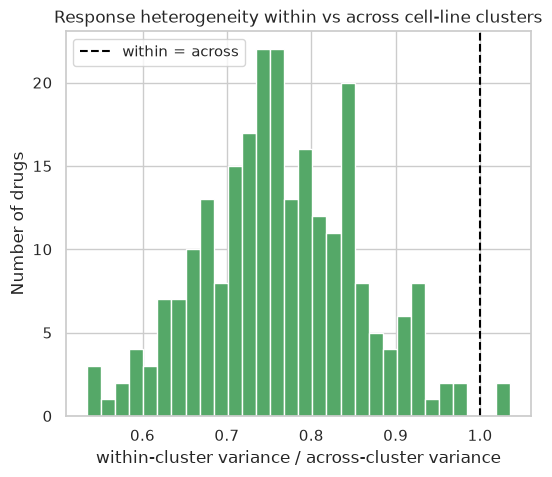

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(variance_df["ratio"].dropna(), bins=30, color="#55A868", edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", label="within = across")
ax.set_xlabel("within-cluster variance / across-cluster variance")
ax.set_ylabel("Number of drugs")
ax.set_title("Response heterogeneity within vs across cell-line clusters")
ax.legend()
fig.savefig(FIGURES_DIR / "fig5_within_vs_across_variance.png", dpi=200, bbox_inches="tight")

In [44]:
outliers = (
    variance_df[variance_df["ratio"] >= 0.95]
    .sort_values("ratio", ascending=False)
)

pair_counts = pairs.groupby(COL_DRUG).agg(
    n_pairs=("cell_cluster", "size"),
    n_clusters_represented=("cell_cluster", "nunique"),
)

outliers = outliers.set_index("drug").join(pair_counts)
outliers

,within_cluster_var,across_cluster_var,ratio,n_pairs,n_clusters_represented
drug,,,,,
GSK269962A,2.106617,2.035370,1.035004,212,8
Sepantronium bromide,2.760137,2.681936,1.029159,827,8
AZD2014,2.105849,2.147197,0.980743,644,8
BMS-536924,1.781519,1.832151,0.972365,827,8
123829,2.592014,2.690892,0.963255,643,8
Cediranib,1.387060,1.448100,0.957848,827,8


## Notes & next steps

- **Ratio well below 1** → cell-line clusters explain real response structure; LCO/LTO
  are testing something real, not just noise.
- **Ratio near 1** → clusters (as currently defined) don't capture response-relevant
  structure; worth revisiting `N_CLUSTERS_CELL` or the HVG feature set.
- The ARI between RNA-based and protein-based clusters tells us how much *new*
  structure protein actually contributes at the cell-line level — low ARI is a good
  sign for the multimodal hypothesis, high ARI suggests redundancy.
- In the baseline notebooks (05/06), we can stratify LCO/LTO results by whether a held-out
  cell line was cluster-isolated or cluster-adjacent to the training set — a direct,
  data-grounded probe of the Simpson's-paradox concern from the DrEval paper (Fig. 3).